# SCB Bow/Turn YOLOv7 Inference Notebook

This notebook validates the legacy YOLOv7 `best.pt` checkpoint for BowHead/TurnHead behavior on local SCB data.

It will:
- load classes from dataset YAML,
- load the model via `load_legacy_yolov7_detector`,
- auto-select samples that cover both classes from label files,
- run inference + draw predictions/GT,
- save annotated JPG files and a montage image.

In [1]:
import os
import sys
import random
from datetime import datetime
from pathlib import Path
from typing import Dict, List, Optional, Set, Tuple

import numpy as np
import torch
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

try:
    import yaml
except Exception:
    yaml = None

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Python: {sys.version.split()[0]}")
print(f"Torch: {torch.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Pillow: {Image.__version__}")
print(f"Matplotlib: {plt.matplotlib.__version__}")
print(f"PyYAML: {getattr(yaml, '__version__', 'not-installed')}")
print(f"Device: {DEVICE}")

Python: 3.11.8
Torch: 2.1.2+cpu
NumPy: 1.24.3
Pillow: 10.1.0
Matplotlib: 3.10.8
PyYAML: 6.0.3
Device: cpu


In [2]:
def find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "backend" / "models" / "yolo.py").exists():
            return candidate
    raise FileNotFoundError("Could not find repository root containing backend/models/yolo.py")


def load_class_names(yaml_path: Path) -> List[str]:
    fallback = ["BowHead", "TurnHead"]
    if not yaml_path.exists():
        print(f"[WARN] YAML not found at {yaml_path}. Using fallback classes: {fallback}")
        return fallback

    if yaml is None:
        print(f"[WARN] PyYAML not available. Using fallback classes: {fallback}")
        return fallback

    with yaml_path.open("r", encoding="utf-8") as f:
        data = yaml.safe_load(f) or {}

    names = data.get("names", fallback)
    if isinstance(names, dict):
        names = [names[i] for i in sorted(names.keys())]
    names = [str(x) for x in names]

    if len(names) < 2:
        print(f"[WARN] Unexpected class names in YAML: {names}. Using fallback classes: {fallback}")
        return fallback

    return names


REPO_ROOT = find_repo_root(Path.cwd())
DATASET_ROOT = REPO_ROOT / "YOLO" / "SCB-Dataset" / "SCB_BowTurnHead_20250509"
NESTED_DATA_ROOT = DATASET_ROOT / "SCB_BowTurnHead_20250509" / "SCB5-Turn-Bow-Head-2024-9-17"
IMAGES_ROOT = NESTED_DATA_ROOT / "images"
LABELS_ROOT = NESTED_DATA_ROOT / "labels"
YAML_PATH = DATASET_ROOT / "SCB_BowTurnHead_20250509.yaml"
WEIGHTS_PATH = DATASET_ROOT / "exp" / "exp" / "weights" / "best.pt"

OUTPUT_ROOT = REPO_ROOT / "inference_outputs"
RUN_OUTPUT_DIR = OUTPUT_ROOT / datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repo root: {REPO_ROOT}")
print(f"Weights: {WEIGHTS_PATH}")
print(f"Labels root exists: {LABELS_ROOT.exists()}")
print(f"Images root exists: {IMAGES_ROOT.exists()}")
print(f"Run output dir: {RUN_OUTPUT_DIR}")

Repo root: D:\Projects\DoAnDN
Weights: D:\Projects\DoAnDN\YOLO\SCB-Dataset\SCB_BowTurnHead_20250509\exp\exp\weights\best.pt
Labels root exists: True
Images root exists: True
Run output dir: D:\Projects\DoAnDN\inference_outputs\20260416_164522


In [3]:
CLASS_NAMES = load_class_names(YAML_PATH)
CLASS_COLORS = {
    "pred": (0, 150, 255),      # orange-ish
    "gt": (0, 220, 120),        # green
}

# Import legacy YOLOv7 loader
backend_path = str(REPO_ROOT / "backend")
if backend_path not in sys.path:
    sys.path.insert(0, backend_path)

from models.yolo import load_legacy_yolov7_detector  # noqa: E402

detector = load_legacy_yolov7_detector(
    weights_path=WEIGHTS_PATH,
    names=CLASS_NAMES,
    device=DEVICE,
)

print("Loaded classes:", CLASS_NAMES)
print("Model loaded with legacy YOLOv7 loader.")

Loaded classes: ['BowHead', 'TurnHead']
Model loaded with legacy YOLOv7 loader.


In [4]:
USE_ULTRA_FALLBACK = False
ultra_model = None
INFERENCE_ERRORS = []


class EmptyResult:
    def __init__(self):
        self.boxes = []


def run_detector(image_np: np.ndarray, conf: float = 0.25):
    global USE_ULTRA_FALLBACK, ultra_model

    if not USE_ULTRA_FALLBACK:
        try:
            return detector(image_np, conf=conf, verbose=False)
        except Exception as ex:
            msg = f"Legacy YOLOv7 inference failed: {ex}"
            INFERENCE_ERRORS.append(msg)
            print(f"[WARN] {msg}")
            print("[INFO] Switching to Ultralytics fallback for this notebook run.")
            USE_ULTRA_FALLBACK = True

    try:
        if ultra_model is None:
            from ultralytics import YOLO  # imported lazily
            ultra_model = YOLO(str(WEIGHTS_PATH))
        return ultra_model(image_np, conf=conf, verbose=False)
    except Exception as ex:
        msg = f"Ultralytics fallback failed: {ex}"
        INFERENCE_ERRORS.append(msg)
        print(f"[WARN] {msg}")
        return [EmptyResult()]


print("Detector wrapper ready. Primary path: legacy YOLOv7 loader; fallback: ultralytics YOLO.")

Detector wrapper ready. Primary path: legacy YOLOv7 loader; fallback: ultralytics YOLO.


In [5]:
def yolo_txt_to_xyxy(line: str, width: int, height: int) -> Optional[Tuple[int, float, float, float, float]]:
    parts = line.strip().split()
    if len(parts) < 5:
        return None

    try:
        cls = int(float(parts[0]))
        x_c = float(parts[1]) * width
        y_c = float(parts[2]) * height
        bw = float(parts[3]) * width
        bh = float(parts[4]) * height
    except ValueError:
        return None

    x1 = max(0.0, x_c - bw / 2.0)
    y1 = max(0.0, y_c - bh / 2.0)
    x2 = min(float(width), x_c + bw / 2.0)
    y2 = min(float(height), y_c + bh / 2.0)
    return cls, x1, y1, x2, y2


def resolve_image_for_label(label_file: Path, split: str) -> Optional[Path]:
    stem = label_file.stem
    base_dir = IMAGES_ROOT / split
    for ext in [".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"]:
        candidate = base_dir / f"{stem}{ext}"
        if candidate.exists():
            return candidate
    return None


def parse_label_classes(label_file: Path) -> Set[int]:
    classes = set()
    with label_file.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            cls = int(float(line.split()[0]))
            classes.add(cls)
    return classes


def collect_label_records() -> List[Dict]:
    records = []
    for split in ["train", "val"]:
        split_dir = LABELS_ROOT / split
        if not split_dir.exists():
            continue
        for label_file in sorted(split_dir.glob("*.txt")):
            try:
                classes = parse_label_classes(label_file)
            except Exception:
                continue
            image_file = resolve_image_for_label(label_file, split)
            if image_file is None:
                continue
            records.append({
                "split": split,
                "label_file": label_file,
                "image_file": image_file,
                "classes": classes,
            })
    return records


def select_class_coverage_samples(records: List[Dict], per_class: int = 3, seed: int = 42):
    rng = random.Random(seed)
    c0 = [r for r in records if 0 in r["classes"]]
    c1 = [r for r in records if 1 in r["classes"]]

    pick0 = rng.sample(c0, k=min(per_class, len(c0))) if c0 else []
    pick1 = rng.sample(c1, k=min(per_class, len(c1))) if c1 else []

    unique = {}
    for rec in [*pick0, *pick1]:
        unique[str(rec["image_file"])] = rec

    selected = list(unique.values())
    selected.sort(key=lambda r: str(r["image_file"]))

    return {
        "selected": selected,
        "picked_class0": pick0,
        "picked_class1": pick1,
        "available_class0": len(c0),
        "available_class1": len(c1),
    }


records = collect_label_records()
selection = select_class_coverage_samples(records, per_class=3, seed=SEED)
selected_records = selection["selected"]

print(f"Total label records: {len(records)}")
print(f"Available class 0 files: {selection['available_class0']}")
print(f"Available class 1 files: {selection['available_class1']}")
print(f"Picked class 0 samples: {len(selection['picked_class0'])}")
print(f"Picked class 1 samples: {len(selection['picked_class1'])}")
print(f"Unique images selected for inference: {len(selected_records)}")

if len(selection["picked_class0"]) < 3 or len(selection["picked_class1"]) < 3:
    print("[WARN] Could not pick 3 samples for one or both classes due to dataset availability.")

Total label records: 2410
Available class 0 files: 1001
Available class 1 files: 2098
Picked class 0 samples: 3
Picked class 1 samples: 3
Unique images selected for inference: 6


In [6]:
def extract_predictions(result_obj, class_names: List[str]):
    preds = []
    boxes = getattr(result_obj, "boxes", [])
    if boxes is None:
        return preds

    for b in boxes:
        try:
            conf = float(b.conf[0].item() if hasattr(b.conf[0], "item") else b.conf[0])
            cls_id = int(b.cls[0].item() if hasattr(b.cls[0], "item") else b.cls[0])
            xyxy = b.xyxy[0].tolist() if hasattr(b.xyxy[0], "tolist") else list(b.xyxy[0])
        except Exception:
            continue

        label = class_names[cls_id] if 0 <= cls_id < len(class_names) else f"class_{cls_id}"
        preds.append({
            "class_id": cls_id,
            "label": label,
            "conf": conf,
            "xyxy": xyxy,
        })
    return preds


def read_gt_boxes(label_file: Path, image_size: Tuple[int, int], class_names: List[str]):
    width, height = image_size
    gt = []
    if not label_file.exists():
        return gt

    with label_file.open("r", encoding="utf-8") as f:
        for line in f:
            parsed = yolo_txt_to_xyxy(line, width, height)
            if parsed is None:
                continue
            cls_id, x1, y1, x2, y2 = parsed
            label = class_names[cls_id] if 0 <= cls_id < len(class_names) else f"class_{cls_id}"
            gt.append({
                "class_id": cls_id,
                "label": label,
                "xyxy": [x1, y1, x2, y2],
            })
    return gt


def draw_boxes(image_pil: Image.Image, pred_boxes: List[Dict], gt_boxes: List[Dict]):
    annotated = image_pil.copy()
    draw = ImageDraw.Draw(annotated)

    for item in gt_boxes:
        x1, y1, x2, y2 = item["xyxy"]
        draw.rectangle([x1, y1, x2, y2], outline=CLASS_COLORS["gt"], width=2)
        draw.text((x1 + 2, max(0, y1 - 12)), f"GT:{item['label']}", fill=CLASS_COLORS["gt"])

    for item in pred_boxes:
        x1, y1, x2, y2 = item["xyxy"]
        draw.rectangle([x1, y1, x2, y2], outline=CLASS_COLORS["pred"], width=3)
        draw.text((x1 + 2, y1 + 2), f"{item['label']} {item['conf']:.2f}", fill=CLASS_COLORS["pred"])

    return annotated

Saved 6 annotated images to: D:\Projects\DoAnDN\inference_outputs\20260416_164522
- annotated_01_0002054.jpg: preds=0, gt=8
- annotated_02_10_000989.jpg: preds=11, gt=8
- annotated_03_15_000154.jpg: preds=3, gt=1
- annotated_04_16_000739.jpg: preds=8, gt=5
- annotated_05_18_000420.jpg: preds=2, gt=3
- annotated_06_23_001841.jpg: preds=2, gt=7


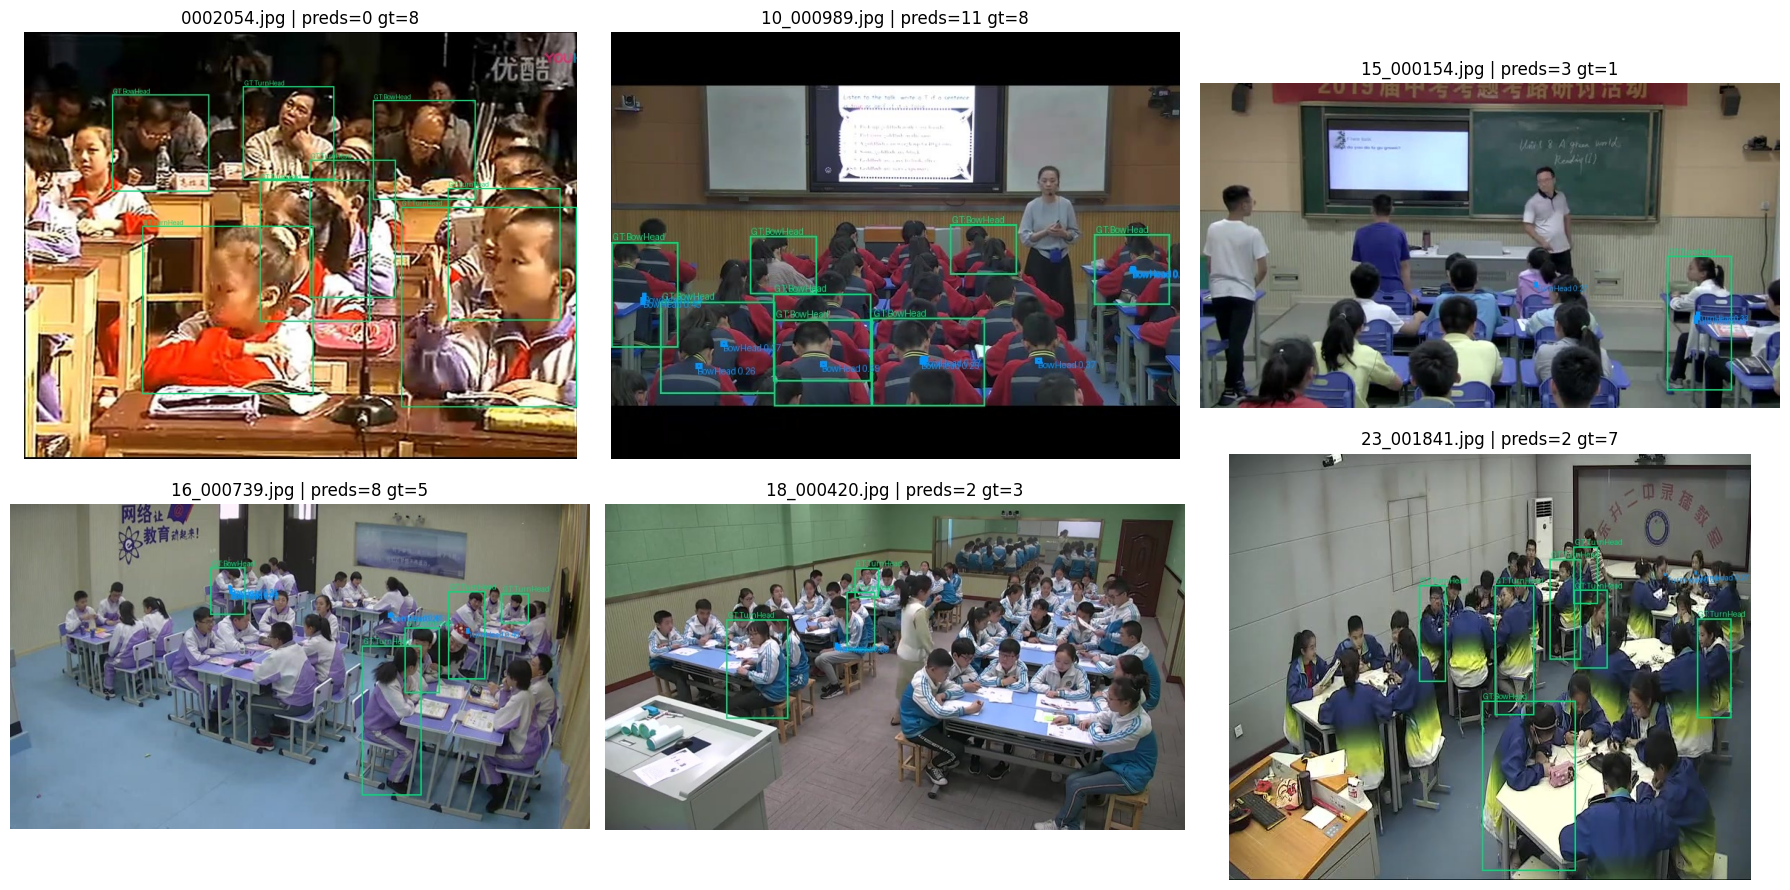

Montage saved: D:\Projects\DoAnDN\inference_outputs\20260416_164522\montage.jpg
Predicted class totals:
- Class 0 (BowHead): 16
- Class 1 (TurnHead): 10


In [7]:
CONF_THRESHOLD = 0.25

run_rows = []
predicted_class_counts = {0: 0, 1: 0}
saved_files = []

if not selected_records:
    raise RuntimeError("No selected records found. Check labels/images paths and dataset contents.")

for idx, rec in enumerate(selected_records, start=1):
    image_path = rec["image_file"]
    label_path = rec["label_file"]

    image_pil = Image.open(image_path).convert("RGB")
    image_np = np.array(image_pil)

    results = run_detector(image_np, conf=CONF_THRESHOLD)
    result_obj = results[0] if isinstance(results, (list, tuple)) and len(results) > 0 else results

    pred_boxes = extract_predictions(result_obj, CLASS_NAMES)
    for p in pred_boxes:
        if p["class_id"] in predicted_class_counts:
            predicted_class_counts[p["class_id"]] += 1

    gt_boxes = read_gt_boxes(label_path, image_pil.size, CLASS_NAMES)
    annotated = draw_boxes(image_pil, pred_boxes, gt_boxes)

    out_name = f"annotated_{idx:02d}_{image_path.stem}.jpg"
    out_path = RUN_OUTPUT_DIR / out_name
    annotated.save(out_path, format="JPEG", quality=95)
    saved_files.append(out_path)

    run_rows.append({
        "image_path": image_path,
        "label_path": label_path,
        "annotated_path": out_path,
        "pred_count": len(pred_boxes),
        "gt_count": len(gt_boxes),
        "pred_boxes": pred_boxes,
    })

print(f"Saved {len(saved_files)} annotated images to: {RUN_OUTPUT_DIR}")
for row in run_rows:
    print(f"- {row['annotated_path'].name}: preds={row['pred_count']}, gt={row['gt_count']}")

cols = 3
rows = int(np.ceil(len(run_rows) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4.5 * rows))
if rows == 1 and cols == 1:
    axes = np.array([[axes]])
elif rows == 1:
    axes = np.array([axes])
elif cols == 1:
    axes = np.array([[ax] for ax in axes])

axes_flat = axes.flatten()
for ax in axes_flat:
    ax.axis("off")

for i, row in enumerate(run_rows):
    img = Image.open(row["annotated_path"]).convert("RGB")
    axes_flat[i].imshow(img)
    axes_flat[i].set_title(f"{row['image_path'].name} | preds={row['pred_count']} gt={row['gt_count']}")
    axes_flat[i].axis("off")

plt.tight_layout()
montage_path = RUN_OUTPUT_DIR / "montage.jpg"
fig.savefig(montage_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Montage saved: {montage_path}")
print("Predicted class totals:")
print(f"- Class 0 ({CLASS_NAMES[0]}): {predicted_class_counts.get(0, 0)}")
print(f"- Class 1 ({CLASS_NAMES[1]}): {predicted_class_counts.get(1, 0)}")

if predicted_class_counts.get(0, 0) == 0:
    print(f"[WARN] Zero predictions for class 0 ({CLASS_NAMES[0]}) at conf={CONF_THRESHOLD}")
if predicted_class_counts.get(1, 0) == 0:
    print(f"[WARN] Zero predictions for class 1 ({CLASS_NAMES[1]}) at conf={CONF_THRESHOLD}")

if INFERENCE_ERRORS:
    print("\nInference errors encountered:")
    for msg in sorted(set(INFERENCE_ERRORS)):
        print(f"- {msg}")